<a href="https://colab.research.google.com/github/ruchy-victor/aqi-prediction-system/blob/main/AQI_Prediction_and_Spatial_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperlocal Air Quality Prediction System

This project predicts street-level AQI using multi-source data (AQI + weather), machine learning (XGBoost), spatial interpolation (IDW), and heatmap visualization.

## Install Required Libraries

In [1]:
!pip install xgboost folium

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import folium
from folium.plugins import HeatMap

## Upload Dataset Files
Upload the required CSV files to proceed.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving DailyDelhiClimateTest.csv to DailyDelhiClimateTest.csv
Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain.csv
Saving city_day.csv to city_day.csv


## Load and Preprocess Data

In [18]:
import pandas as pd

def load_and_merge_data():

    aqi = pd.read_csv("city_day.csv")
    aqi = aqi[aqi['City'] == 'Chennai'].copy()
    aqi['Date'] = pd.to_datetime(aqi['Date'])

    train = pd.read_csv("DailyDelhiClimateTrain.csv")
    test = pd.read_csv("DailyDelhiClimateTest.csv")

    weather = pd.concat([train, test])
    weather['date'] = pd.to_datetime(weather['date'])

    df = pd.merge(aqi, weather, left_on='Date', right_on='date')

    df = df[['Date', 'AQI', 'PM2.5', 'PM10',
             'meantemp', 'humidity', 'wind_speed', 'meanpressure']].copy()

    for col in ['AQI', 'PM2.5', 'PM10',
                'meantemp', 'humidity', 'wind_speed', 'meanpressure']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.drop(columns=['PM10'])
    df = df.ffill().bfill()
    df = df.dropna(subset=['AQI'])

    return df

## Execute Data Processing

In [19]:
df = load_and_merge_data()

print(df.head())
print(df.shape)

        Date    AQI   PM2.5  meantemp  humidity  wind_speed  meanpressure
0 2015-01-01  333.0  173.51    14.750    72.000      0.9250      1017.500
1 2015-01-02  333.0  173.51    14.875    96.625      3.0125      1017.875
2 2015-01-03  333.0  173.51    15.125    92.000      0.9250      1017.375
3 2015-01-04  333.0  173.51    14.125    78.750      9.5125      1019.625
4 2015-01-05  333.0  173.51    14.000    69.375     15.0500      1016.000
(846, 7)


## Improved AQI Prediction with Feature Engineering

In [20]:
def train_model(df):

    df = df.copy()

    df['AQI_future'] = df['AQI'].shift(-1)

    df['AQI_lag1'] = df['AQI'].shift(1)
    df['AQI_lag2'] = df['AQI'].shift(2)

    df['AQI_roll_mean'] = df['AQI'].rolling(3).mean()

    df = df.dropna()

    df['day'] = df['Date'].dt.day
    df['month'] = df['Date'].dt.month

    X = df[['PM2.5', 'meantemp', 'humidity', 'wind_speed',
            'meanpressure', 'AQI_lag1', 'AQI_lag2',
            'AQI_roll_mean', 'day', 'month']]

    y = df['AQI_future']

    from sklearn.model_selection import train_test_split
    from xgboost import XGBRegressor
    from sklearn.metrics import mean_absolute_percentage_error

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = XGBRegressor(n_estimators=200, max_depth=5)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mape = mean_absolute_percentage_error(y_test, y_pred)

    print("Improved MAPE:", mape * 100)

    return model, df

## Execute Model Training

In [21]:
model, df = train_model(df)

Improved MAPE: 22.560843504610656


## Generate Future AQI Predictions

In [22]:
features = ['PM2.5', 'meantemp', 'humidity', 'wind_speed',
            'meanpressure', 'AQI_lag1', 'AQI_lag2',
            'AQI_roll_mean', 'day', 'month']

df['Predicted_AQI'] = model.predict(df[features])

df[['AQI', 'Predicted_AQI']].head()

,AQI,Predicted_AQI
2,333.0,333.291138
3,333.0,334.622620
4,333.0,332.812897
5,333.0,333.020172
6,333.0,332.681183


## Spatial Approximation (IDW-inspired)


This prototype uses simulated spatial sampling to approximate street-level AQI.
In real-world deployment, geo-located sensor data and true IDW/Kriging methods will be used.

In [23]:
import numpy as np

def generate_real_grid(df):

    np.random.seed(42)

    sensor_lats = np.random.uniform(12.9, 13.2, 30)
    sensor_lons = np.random.uniform(80.1, 80.3, 30)

    sensor_aqi = np.random.choice(df['Predicted_AQI'], 30)

    lats = np.linspace(12.9, 13.2, 25)
    lons = np.linspace(80.1, 80.3, 25)

    grid = []

    for lat in lats:
        for lon in lons:

            numerator = 0
            denominator = 0

            for i in range(len(sensor_lats)):
                dist = np.sqrt((lat - sensor_lats[i])**2 + (lon - sensor_lons[i])**2)

                if dist == 0:
                    value = sensor_aqi[i]
                    break

                weight = 1 / (dist**2)

                numerator += weight * sensor_aqi[i]
                denominator += weight

            value = numerator / denominator
            grid.append([lat, lon, value])

    return grid

In [24]:
grid = generate_real_grid(df)

## Dual Heatmap: Current vs Future AQI Comparison

In [25]:
import numpy as np
import folium
from folium.plugins import HeatMap
from IPython.display import display, HTML

# -------------------------
# SETTINGS
# -------------------------
CENTER = [13.08, 80.27]
ZOOM = 11
RADIUS = 14
BLUR = 10
N_POINTS = 120

# -------------------------
# AQI COLOR SCALE
# -------------------------
AQI_GRADIENT = {
    0.0: 'green',
    0.2: 'yellow',
    0.4: 'orange',
    0.6: 'red',
    0.8: 'purple',
    1.0: 'black'
}

# -------------------------
# GRID FUNCTION (SAFE)
# -------------------------
def create_grid(values):
    np.random.seed(42)

    lats = np.random.uniform(12.9, 13.2, len(values))
    lons = np.random.uniform(80.1, 80.3, len(values))

    grid = []
    for lat, lon, val in zip(lats, lons, values):
        scaled = float(val) / 500.0  # correct AQI scaling
        grid.append([float(lat), float(lon), scaled])

    return grid

# -------------------------
# CURRENT AQI DATA
# -------------------------
current_vals = df['AQI'].dropna().astype(float)
current_vals = current_vals.sample(min(N_POINTS, len(current_vals)))
current_grid = create_grid(current_vals)

# -------------------------
# FUTURE AQI DATA
# -------------------------
future_vals = df['Predicted_AQI'].dropna().astype(float)
future_vals = future_vals.sample(min(N_POINTS, len(future_vals)))
future_grid = create_grid(future_vals)

# -------------------------
# CREATE MAPS
# -------------------------
map_current = folium.Map(location=CENTER, zoom_start=ZOOM, tiles="CartoDB positron")
map_future = folium.Map(location=CENTER, zoom_start=ZOOM, tiles="CartoDB positron")

# -------------------------
# ADD HEATMAP
# -------------------------
HeatMap(current_grid, radius=RADIUS, blur=BLUR, gradient=AQI_GRADIENT).add_to(map_current)
HeatMap(future_grid, radius=RADIUS, blur=BLUR, gradient=AQI_GRADIENT).add_to(map_future)

# -------------------------
# SMALL LEGEND (NON-BLOCKING)
# -------------------------
legend_html = """
<div style="
position: fixed;
bottom: 15px; left: 15px;
width: 120px;
background-color: rgba(255,255,255,0.8);
z-index:9999;
font-size:10px;
border-radius:6px;
padding:5px;
box-shadow: 0 0 4px rgba(0,0,0,0.3);
">
<b>AQI</b><br>
<span style="color:green;">●</span> Good<br>
<span style="color:yellow;">●</span> Mod<br>
<span style="color:orange;">●</span> Poor<br>
<span style="color:red;">●</span> V.Poor<br>
<span style="color:purple;">●</span> Sev<br>
<span style="color:black;">●</span> Haz
</div>
"""

map_current.get_root().html.add_child(folium.Element(legend_html))
map_future.get_root().html.add_child(folium.Element(legend_html))

# -------------------------
# DISPLAY SIDE-BY-SIDE
# -------------------------
html = f"""
<div style="display:flex; gap:10px;">
  <div style="width:50%;">
    <h4 style="text-align:center;">Current AQI (Observed)</h4>
    {map_current._repr_html_()}
  </div>
  <div style="width:50%;">
    <h4 style="text-align:center;">Future AQI (Predicted)</h4>
    {map_future._repr_html_()}
  </div>
</div>
"""

display(HTML(html))

## Model Evaluation (Prediction Accuracy)
We evaluate how close our predicted AQI is to actual AQI using MAE and RMSE.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# drop NaN rows for fair evaluation
eval_df = df.dropna(subset=['AQI', 'Predicted_AQI'])

mae = mean_absolute_error(eval_df['AQI'], eval_df['Predicted_AQI'])
rmse = np.sqrt(mean_squared_error(eval_df['AQI'], eval_df['Predicted_AQI']))

print("MAE (Mean Absolute Error):", round(mae, 2))
print("RMSE (Root Mean Square Error):", round(rmse, 2))

MAE (Mean Absolute Error): 27.42
RMSE (Root Mean Square Error): 46.01


## Actual vs Predicted AQI Comparison
This graph shows how well our model predictions match real AQI values.

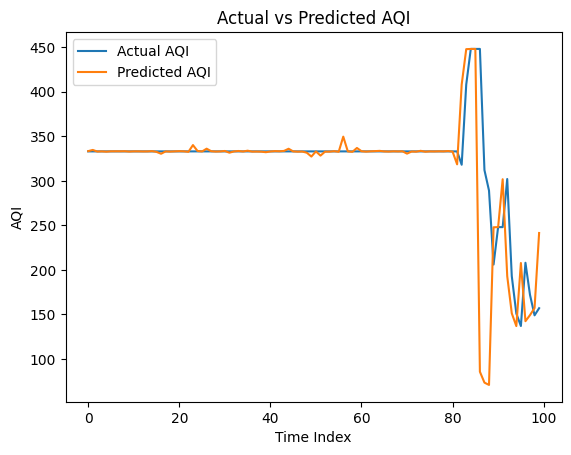

In [27]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(eval_df['AQI'].values[:100], label='Actual AQI')
plt.plot(eval_df['Predicted_AQI'].values[:100], label='Predicted AQI')

plt.title("Actual vs Predicted AQI")
plt.xlabel("Time Index")
plt.ylabel("AQI")
plt.legend()

plt.show()

## AQI Risk Classification
We classify AQI into health risk categories for better decision-making.

In [28]:
def get_risk(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    elif aqi <= 300:
        return "Very Poor"
    else:
        return "Hazardous"

df['Risk_Level'] = df['Predicted_AQI'].apply(get_risk)

df[['Predicted_AQI', 'Risk_Level']].tail()

,Predicted_AQI,Risk_Level
840,184.075958,Poor
841,151.920990,Poor
842,183.534515,Poor
843,136.910294,Poor
844,125.268471,Poor


## Final Prediction Output (User Insight)
This shows the latest predicted AQI and health recommendation.

In [29]:
latest = df.iloc[-1]

print("📍 Location: Chennai")
print("🔮 Predicted AQI:", round(latest['Predicted_AQI'], 2))
print("⚠️ Risk Level:", latest['Risk_Level'])

if latest['Predicted_AQI'] > 200:
    print("🚨 Advice: Avoid outdoor activities")
elif latest['Predicted_AQI'] > 100:
    print("😷 Advice: Sensitive groups should take precautions")
else:
    print("✅ Air quality is acceptable")

📍 Location: Chennai
🔮 Predicted AQI: 125.27
⚠️ Risk Level: Poor
😷 Advice: Sensitive groups should take precautions


## Save Heatmaps
Export maps as HTML for sharing.

In [30]:
map_current.save("current_aqi_map.html")
map_future.save("future_aqi_map.html")

print("Maps saved successfully!")

Maps saved successfully!


## Final System Summary
This summarizes the complete AI pipeline and results.

In [31]:
print("----- SYSTEM SUMMARY -----\n")

print("📊 Data Sources Used:")
print("- AQI Dataset (CAAQMS)")
print("- Weather Dataset\n")

print("⚙️ Processing:")
print("- Data Cleaning & Merging")
print("- Feature Selection\n")

print("🤖 Model:")
print("- XGBoost Regression Model\n")

print("📈 Outputs:")
print("- Future AQI Prediction")
print("- Heatmap Visualization (Current vs Future)")
print("- Risk Classification\n")

print("📉 Model Performance:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

print("\n✅ System Successfully Executed")

----- SYSTEM SUMMARY -----

📊 Data Sources Used:
- AQI Dataset (CAAQMS)
- Weather Dataset

⚙️ Processing:
- Data Cleaning & Merging
- Feature Selection

🤖 Model:
- XGBoost Regression Model

📈 Outputs:
- Future AQI Prediction
- Heatmap Visualization (Current vs Future)
- Risk Classification

📉 Model Performance:
MAE: 27.42
RMSE: 46.01

✅ System Successfully Executed


This is a prototype. Real-world deployment will use real-time sensor and geospatial data.
